In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Load the dataset
X_train_val = pd.read_csv('Data/pirate_pain_train.csv')
y_train_val = pd.read_csv('Data/pirate_pain_train_labels.csv')
X_test = pd.read_csv('Data/pirate_pain_test.csv')

df = X_train_val.merge(y_train_val, on="sample_index", how="left")

In [3]:
# Drop highly correlated or irrelevant features

df.drop(columns=["joint_30"], inplace=True)
df.drop(columns=["n_legs"], inplace=True)
df.drop(columns=["n_hands"], inplace=True)

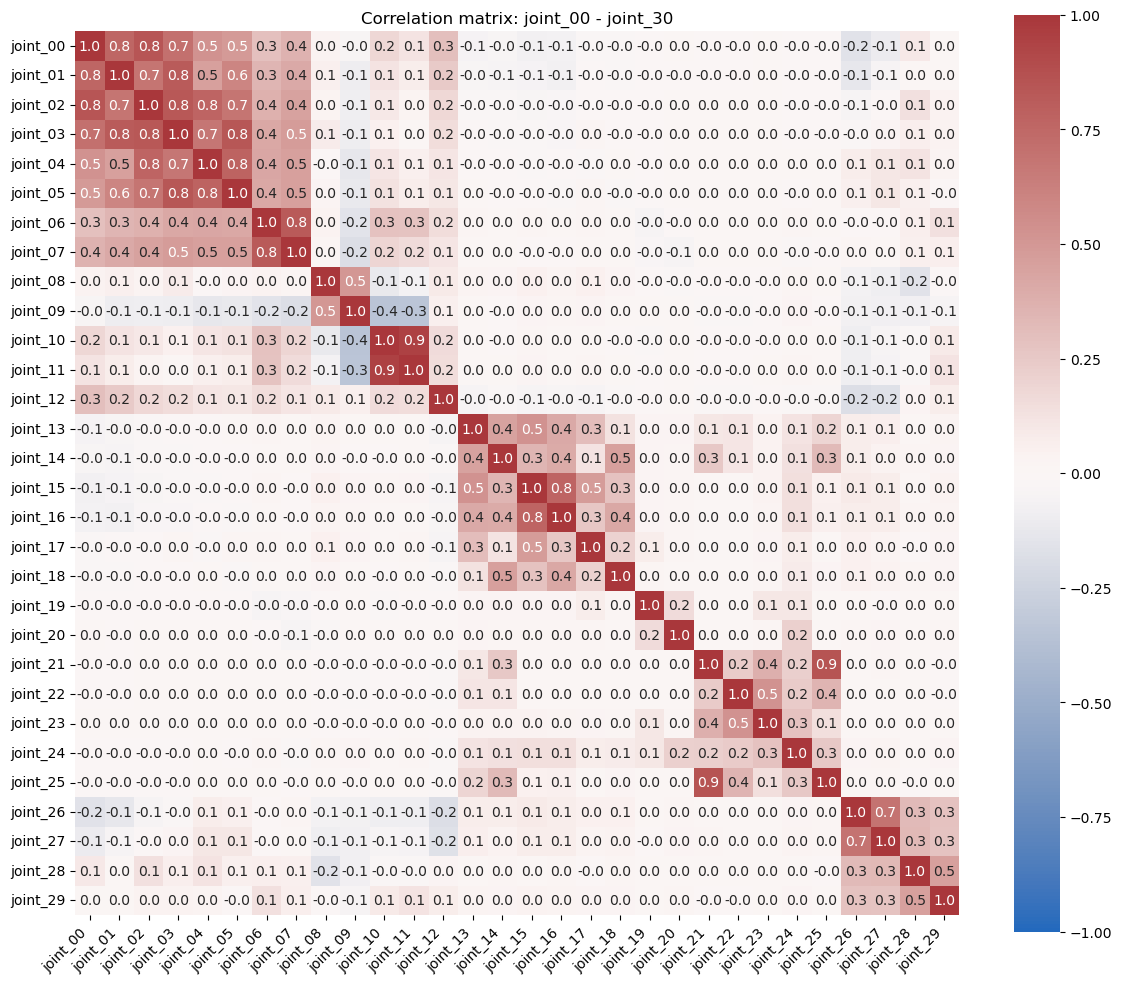

In [4]:
# Confusion matrix con valori numerici

import seaborn as sns

cols = [f"joint_{i:02d}" for i in range(30)]
corr = df[cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="vlag", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix: joint_00 - joint_30")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
survey_cols = ["pain_survey_1", "pain_survey_2", "pain_survey_3", "pain_survey_4"]
body_cols = ["n_eyes"]
cont_cols = [c for c in df.columns if c.startswith("joint_")]
time_cols = ["time"]

In [6]:
from sklearn.preprocessing import LabelEncoder

survey_encoders = {col: LabelEncoder().fit(df[col]) for col in survey_cols}
body_encoders   = {col: LabelEncoder().fit(df[col]) for col in body_cols}

for col, enc in survey_encoders.items():
    df[col] = enc.transform(df[col])
    X_test[col] = enc.transform(X_test[col])

for col, enc in body_encoders.items():
    df[col] = enc.transform(df[col])
    X_test[col] = enc.transform(X_test[col])

survey_cardinality = [len(enc.classes_) for enc in survey_encoders.values()]
body_cardinality   = [len(enc.classes_) for enc in body_encoders.values()]

In [7]:
# Apply label mapping to y_train_val
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

df['label'] = df['label'].map(label_mapping)

In [8]:
len(df[cont_cols])

105760

In [9]:
grouped = df.groupby("sample_index")
print("Number of samples:", len(grouped))

cont_tensors, survey_tensors, body_tensors, time_tensors, labels = [], [], [], [], []

for _, group in grouped:
    cont_tensors.append(torch.tensor(group[cont_cols].values, dtype=torch.float32))
    survey_tensors.append(torch.tensor(group[survey_cols].values, dtype=torch.long))
    body_tensors.append(torch.tensor(group[body_cols].values, dtype=torch.long))
    time_tensors.append(torch.tensor(group[time_cols].values, dtype=torch.float32))
    labels.append(torch.tensor(int(group["label"].iloc[0]), dtype=torch.long))
    
grouped_test = X_test.groupby("sample_index")

cont_tensors_test, survey_tensors_test, body_tensors_test, time_tensors_test = [], [], [], []
for _, group in grouped_test:
    cont_tensors_test.append(torch.tensor(group[cont_cols].values, dtype=torch.float32))
    survey_tensors_test.append(torch.tensor(group[survey_cols].values, dtype=torch.long))
    body_tensors_test.append(torch.tensor(group[body_cols].values, dtype=torch.long))
    time_tensors_test.append(torch.tensor(group[time_cols].values, dtype=torch.float32))

Number of samples: 661


In [10]:
# since every sample has the same length this padding is not strictly necessary but it's good practice

from torch.nn.utils.rnn import pad_sequence

cont_padded   = pad_sequence(cont_tensors,   batch_first=True)  
survey_padded = pad_sequence(survey_tensors, batch_first=True)  
body_padded   = pad_sequence(body_tensors,   batch_first=True)  
time_padded  = pad_sequence(time_tensors,  batch_first=True)
labels_tensor = torch.stack(labels)                           

cont_padded_test   = pad_sequence(cont_tensors_test,   batch_first=True)
survey_padded_test = pad_sequence(survey_tensors_test, batch_first=True)
body_padded_test   = pad_sequence(body_tensors_test,   batch_first=True)
time_padded_test  = pad_sequence(time_tensors_test,  batch_first=True)


print(cont_padded.shape)
print(survey_padded.shape)
print(body_padded.shape)
print(time_padded.shape)
print(labels_tensor.shape)
print(cont_padded_test.shape)
print(survey_padded_test.shape) 
print(body_padded_test.shape)
print(time_padded_test.shape)

torch.Size([661, 160, 30])
torch.Size([661, 160, 4])
torch.Size([661, 160, 1])
torch.Size([661, 160, 1])
torch.Size([661])
torch.Size([1324, 160, 30])
torch.Size([1324, 160, 4])
torch.Size([1324, 160, 1])
torch.Size([1324, 160, 1])


In [11]:
X = {"cont": cont_padded, "survey": survey_padded, "body": body_padded, "time": time_padded}
y = labels_tensor
X_test = {"cont": cont_padded_test, "survey": survey_padded_test, "body": body_padded_test, "time": time_padded_test}

In [12]:
print(X["cont"].shape)


torch.Size([661, 160, 30])


In [13]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    range(len(y)),
    test_size=0.1,
    random_state=0,
    stratify=y
)

In [14]:
def subset(data_dict, indices):
    return {
        key: value[indices] for key, value in data_dict.items()
    }

In [15]:
# Creation of X_train as a dictionary

X_train = subset(X, train_idx)
X_val   = subset(X, val_idx)
y_train, y_val = y[train_idx], y[val_idx]

In [16]:
X_train["cont"].shape

torch.Size([594, 160, 30])

In [17]:
from sklearn.preprocessing import StandardScaler

print(X_train["cont"].shape)
print(X_train["cont"][0])
print(X_train["time"].shape)
#print(X_train["time"][0])

scaler_cont = StandardScaler()


X_train_2d = X_train["cont"].reshape(-1, X_train["cont"].shape[-1])
X_train["cont"] = torch.Tensor(scaler_cont.fit_transform(X_train_2d).reshape(X_train["cont"].shape))
X_val_2d = X_val["cont"].reshape(-1, X_val["cont"].shape[-1])
X_val["cont"] = torch.Tensor(scaler_cont.transform(X_val_2d).reshape(X_val["cont"].shape))


X_test_2d = X_test["cont"].reshape(-1, X_test["cont"].shape[-1])
X_test["cont"] = torch.Tensor(scaler_cont.transform(X_test_2d).reshape(X_test["cont"].shape))

print("After scaling:")

print(X_train["cont"].shape)
print(X_train["cont"][0])
print(X_train["time"].shape)
#print(X_train["time"][0])



torch.Size([594, 160, 30])
tensor([[0.7342, 0.6875, 0.4666,  ..., 0.1187, 0.0196, 0.0226],
        [0.6780, 0.7128, 0.4314,  ..., 0.0220, 0.0079, 0.0049],
        [0.7108, 0.7227, 0.4712,  ..., 0.0630, 0.0214, 0.0262],
        ...,
        [0.7333, 0.7422, 0.4932,  ..., 0.0586, 0.0147, 0.0173],
        [0.7471, 0.7009, 0.4441,  ..., 0.0352, 0.0061, 0.0100],
        [0.7322, 0.6429, 0.4852,  ..., 0.1199, 0.0263, 0.0297]])
torch.Size([594, 160, 1])
After scaling:
torch.Size([594, 160, 30])
tensor([[-1.0089, -1.1324, -1.0392,  ...,  0.7862, -0.4893, -0.5357],
        [-1.2820, -1.0062, -1.1570,  ..., -0.4403, -0.6792, -0.7791],
        [-1.1226, -0.9565, -1.0239,  ...,  0.0793, -0.4595, -0.4865],
        ...,
        [-1.0133, -0.8592, -0.9502,  ...,  0.0236, -0.5678, -0.6080],
        [-0.9463, -1.0657, -1.1145,  ..., -0.2732, -0.7073, -0.7082],
        [-1.0188, -1.3555, -0.9771,  ...,  0.8019, -0.3796, -0.4383]])
torch.Size([594, 160, 1])


In [18]:
# Check if a specific sample from the original dataframe exists in the training or validation set

sample_index = 0

EPS = 1e-3 

target = torch.tensor(df[cont_cols][sample_index:sample_index+1].values, dtype=torch.float32)
coordinates = []

print(len(X_train["cont"]))

print(len(X_val["cont"]))

for i in range(len(X_train["cont"])):
    for j in range(160):
        diff = (X_train["cont"][i][j].unsqueeze(0) - target).abs()
        if (diff < EPS).all():
            print(f"Match found in train at index ({i}, {j})")
            coordinates.append((i, j))

for i in range(len(X_val["cont"])):
    for j in range(160):
        diff = (X_val["cont"][i][j].unsqueeze(0) - target).abs()
        if (diff < EPS).all():
            print(f"Match found in val at index ({i}, {j})")
            coordinates.append((i, j))

for coord in coordinates:
    print(X_train["cont"][coord[0]][coord[1]].unsqueeze(0))


594
67


In [19]:
print(X_train["cont"].shape)
print(X_val["cont"].shape)
print(X_test["cont"].shape)


print(X_train["survey"].shape)
print(X_val["survey"].shape)
print(X_test["survey"].shape)


print(X_train["body"].shape)
print(X_val["body"].shape)
print(X_test["body"].shape)


print(X_train["time"].shape)
print(X_val["time"].shape)
print(X_test["time"].shape)

torch.Size([594, 160, 30])
torch.Size([67, 160, 30])
torch.Size([1324, 160, 30])
torch.Size([594, 160, 4])
torch.Size([67, 160, 4])
torch.Size([1324, 160, 4])
torch.Size([594, 160, 1])
torch.Size([67, 160, 1])
torch.Size([1324, 160, 1])
torch.Size([594, 160, 1])
torch.Size([67, 160, 1])
torch.Size([1324, 160, 1])


In [20]:
def build_windows(X, y, window=100, stride=50):
    """
    Builds windowed subsequences for multi-input data when each sample in X[...] 
    is already a full sequence tensor: [num_samples, seq_len, num_features].
    Works directly with PyTorch tensors.
    """
    cont, survey, body, time = X["cont"], X["survey"], X["body"], X["time"]
    num_samples, seq_len, _ = cont.shape
    print(f"Building windows: num_samples={num_samples}, seq_len={seq_len}, window={window}, stride={stride}")
    cont_windows, survey_windows, body_windows, time_windows = [], [], [], []
    y_labels = []

    for i in range(num_samples):
        cont_seq = cont[i]
        survey_seq = survey[i]
        body_seq = body[i]
        time_seq = time[i]
        label = y[i].item() if torch.is_tensor(y) else y[i]

        pad_len = (window - seq_len % window) % window
        if pad_len > 0:
            cont_seq = torch.cat([cont_seq, torch.zeros(pad_len, cont_seq.shape[1])])
            survey_seq = torch.cat([survey_seq, torch.zeros(pad_len, survey_seq.shape[1], dtype=torch.long)])
            body_seq = torch.cat([body_seq, torch.zeros(pad_len, body_seq.shape[1], dtype=torch.long)])
            time_seq = torch.cat([time_seq, torch.zeros(pad_len, time_seq.shape[1], dtype=torch.long)])

        idx = 0
        while idx + window <= cont_seq.shape[0]:
            cont_windows.append(cont_seq[idx:idx + window].unsqueeze(0))
            survey_windows.append(survey_seq[idx:idx + window].unsqueeze(0))
            body_windows.append(body_seq[idx:idx + window].unsqueeze(0))
            time_windows.append(time_seq[idx:idx + window].unsqueeze(0))
            y_labels.append(label)
            idx += stride

    X_win = {
        "cont": torch.cat(cont_windows, dim=0).float(),
        "survey": torch.cat(survey_windows, dim=0).long(),
        "body": torch.cat(body_windows, dim=0).long(),
        "time": torch.cat(time_windows, dim=0).long(),
    }
    y_win = torch.tensor(y_labels, dtype=torch.long)
    return X_win, y_win


In [21]:
def build_test_windows(X, window=100, stride=50):
    """
    Builds windowed subsequences for test data (no labels).
    Works directly with PyTorch tensors.
    """
    cont, survey, body, time = X["cont"], X["survey"], X["body"], X["time"]
    num_samples, seq_len, _ = cont.shape

    cont_windows, survey_windows, body_windows, time_windows = [], [], [], []

    for i in range(num_samples):
        cont_seq = cont[i]
        survey_seq = survey[i]
        body_seq = body[i]
        time_seq = time[i]

        pad_len = (window - seq_len % window) % window
        if pad_len > 0:
            cont_seq = torch.cat([cont_seq, torch.zeros(pad_len, cont_seq.shape[1])])
            survey_seq = torch.cat([survey_seq, torch.zeros(pad_len, survey_seq.shape[1], dtype=torch.long)])
            body_seq = torch.cat([body_seq, torch.zeros(pad_len, body_seq.shape[1], dtype=torch.long)])
            time_seq = torch.cat([time_seq, torch.zeros(pad_len, time_seq.shape[1], dtype=torch.long)])

        idx = 0
        while idx + window <= cont_seq.shape[0]:
            cont_windows.append(cont_seq[idx:idx + window].unsqueeze(0))
            survey_windows.append(survey_seq[idx:idx + window].unsqueeze(0))
            body_windows.append(body_seq[idx:idx + window].unsqueeze(0))
            time_windows.append(time_seq[idx:idx + window].unsqueeze(0))
            idx += stride

    X_win = {
        "cont": torch.cat(cont_windows, dim=0).float(),
        "survey": torch.cat(survey_windows, dim=0).long(),
        "body": torch.cat(body_windows, dim=0).long(),
        "time": torch.cat(time_windows, dim=0).long(),
    }
    return X_win

In [22]:
WINDOW_SIZE = 32
STRIDE = 16

X_train_seq, y_train_seq = build_windows(X_train, y_train, WINDOW_SIZE, STRIDE)
X_val_seq, y_val_seq = build_windows(X_val, y_val, WINDOW_SIZE, STRIDE)
X_test_seq = build_test_windows(X_test, WINDOW_SIZE, STRIDE)


Building windows: num_samples=594, seq_len=160, window=32, stride=16
Building windows: num_samples=67, seq_len=160, window=32, stride=16


In [23]:
EPS = 1e-3

n = (160 - WINDOW_SIZE) // STRIDE + 1  

sample_index = 0

target = torch.tensor(X_train["cont"][sample_index:sample_index+1], dtype=torch.float32)
coordinates = []
print(df[cont_cols].shape)

num_train_samples = len(X_train["cont"])  
total_windows_train = len(X_train_seq["cont"]) 
print(X_train_seq["cont"].shape) 

num_train_samples = len(X_train["cont"])  
total_windows_val = len(X_val_seq["cont"]) 
print(X_val_seq["cont"].shape) 

print(f"Each original seq has {n} windows")
print(f"Total windows in X_train_seq: {total_windows_train}")
print(f"Total windows in X_val_seq: {total_windows_val}")


for win_idx in range(total_windows_train):
    
    orig_idx = win_idx // n
    local_window = win_idx % n
    base_time = local_window * STRIDE  

    
    for frame_idx in range(WINDOW_SIZE):
        global_time = base_time + frame_idx  
        if global_time >= 160:
            continue  

        diff = (X_train_seq["cont"][win_idx][frame_idx].unsqueeze(0) - target).abs()
        if (diff < EPS).all():
            print(f"Match found in train: sample={orig_idx}, global_time={global_time}, window={local_window}, frame={frame_idx}")
            coordinates.append((win_idx, frame_idx))


for win_idx in range(total_windows_val):
    
    orig_idx = win_idx // n
    local_window = win_idx % n
    base_time = local_window * STRIDE  

    
    for frame_idx in range(WINDOW_SIZE):
        global_time = base_time + frame_idx  
        if global_time >= 160:
            continue  

        diff = (X_val_seq["cont"][win_idx][frame_idx].unsqueeze(0) - target).abs()
        if (diff < EPS).all():
            print(f"Match found in val: sample={orig_idx}, global_time={global_time}, window={local_window}, frame={frame_idx}")
            coordinates.append((win_idx, frame_idx))

/var/folders/b8/rzcf55796dx0l9hv3jf_nxnr0000gn/T/ipykernel_88038/303849204.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(X_train["cont"][sample_index:sample_index+1], dtype=torch.float32)


(105760, 30)
torch.Size([5346, 32, 30])
torch.Size([603, 32, 30])
Each original seq has 9 windows
Total windows in X_train_seq: 5346
Total windows in X_val_seq: 603


In [24]:
print(X_train_seq.keys())
print(X_train_seq["cont"].shape)
print(X_train_seq["cont"][0].shape)
print(X_train_seq["cont"][0][0].shape)

print(X_train_seq["time"].shape)
print(X_train_seq["time"][0].shape)
print(X_train_seq["time"][0][0].shape)

print(y_train_seq.shape)


dict_keys(['cont', 'survey', 'body', 'time'])
torch.Size([5346, 32, 30])
torch.Size([32, 30])
torch.Size([30])
torch.Size([5346, 32, 1])
torch.Size([32, 1])
torch.Size([1])
torch.Size([5346])


In [25]:
# Dump data in files in a format easy to upload on Kaggle as a dataset 

import joblib

joblib.dump(X_train_seq, "X_train_seq.pkl")
joblib.dump(y_train_seq, "y_train_seq.pkl")

joblib.dump(X_val_seq, "X_val_seq.pkl")
joblib.dump(y_val_seq, "y_val_seq.pkl")
joblib.dump(X_test_seq, "X_test_seq.pkl")


['X_test_seq.pkl']